# Setup and Initializing the Environment

In [82]:
%pip install opencv-python

import os
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
import torch

# Portable device selection: Davis CUDA GPU, then Apple Silicon, then CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Using device: mps


In [83]:
# Portable dataset path: use Davis when present, otherwise use the local Mac copy.
davis_dataset_path = Path("/home/cosmos32/AIreferee/data/mvfouls")
mac_dataset_path = Path("/Users/rishideshpande/Downloads/data/soccernet/mvfouls")

if davis_dataset_path.exists():
    dataset_path = davis_dataset_path
elif mac_dataset_path.exists():
    dataset_path = mac_dataset_path
else:
    raise FileNotFoundError(
        "SoccerNet dataset was not found at the Davis or Mac path."
    )

print("Using dataset:", dataset_path)

# Choose exactly one split to preprocess in this run.
# Run this section once for each of: "train", "valid", and "test".
split = "test"

split_path = dataset_path / split

annotations_path = split_path / "annotations.json"

output_path = dataset_path / "processed_frames" / split

# Create the output directory on disk if it doesn't exist yet
output_path.mkdir(parents=True, exist_ok=True)

In [84]:
%pip install scikit-learn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Data Exploration

In [85]:
# Count how many video clips exist across Train, Valid, and Test splits
for split in ["train", "valid", "test"]:

    print(f"\n===== {split.upper()} =====")

    split_path = dataset_path / split

    total = 0

    for action_folder in sorted(split_path.iterdir()):

        if action_folder.is_dir():

            clips = list(action_folder.glob("*.mp4"))

            print(f"{action_folder.name}: {len(clips)} clips")

            total += len(clips)

    print(f"Total clips: {total}")


===== TRAIN =====
action_0: 2 clips
action_1: 2 clips
action_10: 3 clips
action_100: 2 clips
action_1000: 4 clips
action_1001: 3 clips
action_1002: 2 clips
action_1003: 2 clips
action_1004: 2 clips
action_1005: 2 clips
action_1006: 2 clips
action_1007: 3 clips
action_1008: 2 clips
action_1009: 2 clips
action_101: 2 clips
action_1010: 3 clips
action_1011: 2 clips
action_1012: 2 clips
action_1013: 2 clips
action_1014: 2 clips
action_1015: 2 clips
action_1016: 3 clips
action_1017: 2 clips
action_1018: 2 clips
action_1019: 2 clips
action_102: 2 clips
action_1020: 2 clips
action_1021: 2 clips
action_1022: 2 clips
action_1023: 2 clips
action_1024: 2 clips
action_1025: 2 clips
action_1026: 3 clips
action_1027: 2 clips
action_1028: 2 clips
action_1029: 2 clips
action_103: 2 clips
action_1030: 3 clips
action_1031: 3 clips
action_1032: 2 clips
action_1033: 2 clips
action_1034: 3 clips
action_1035: 2 clips
action_1036: 2 clips
action_1037: 2 clips
action_1038: 2 clips
action_1039: 4 clips
action

In [86]:
# Grab the first .mp4 video file to inspect its metadata
video_path = next((dataset_path / "train").rglob("*.mp4"))

print(video_path)

/Users/rishideshpande/Downloads/data/soccernet/mvfouls/train/action_1534/clip_1.mp4


In [87]:
cap = cv2.VideoCapture(str(video_path))

# Extract video properties using OpenCV flags
fps = cap.get(cv2.CAP_PROP_FPS)

frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frames / fps

print(f"FPS: {fps}")
print(f"Frames: {frames}")
print(f"Duration: {duration:.2f} sec")
print(f"Resolution: {width}x{height}")

cap.release() # Release video resource from memory

FPS: 25.0
Frames: 126
Duration: 5.04 sec
Resolution: 398x224


# Annotation Parsing

In [88]:
import json
from collections import Counter

# Load SoccerNet action metadata JSON file
with open(annotations_path, "r") as f:
    annotations = json.load(f)["Actions"]
counter = Counter()

for action_id, info in annotations.items():
    counter[info["Offence"]] += 1

print(counter)

Counter({'Offence': 2495, 'No offence': 324, 'Between': 96, '': 1})


# Video Frame Sampling

In [89]:
def extract_frames(video_path, output_folder, num_frames=12):

    """
    Extracts N evenly-spaced frames from a video clip, resizes them to 224x224, 
    and saves them as JPG images.
    """

    output_folder.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print("No frames found:", video_path)
        return []

    # Generates 12 evenly spaced frame indices (e.g. [0, 10, 20, 30...])
    frame_indices = np.linspace(
        0,
        total_frames-1,
        num_frames,
        dtype=int
    )

    saved_frames = []

    for i, frame_index in enumerate(frame_indices):
        # Jump directly to specific frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        success, frame = cap.read()

        if success:
            # Resize image to standard CNN input size (224x224)
            frame = cv2.resize(frame, (224,224))

            frame_name = f"frame_{i}.jpg"

            frame_path = output_folder / frame_name

            cv2.imwrite(str(frame_path), frame)
            saved_frames.append(str(frame_path))

    cap.release()
    return saved_frames

In [90]:
test_video = next(split_path.rglob("*.mp4"))

test_output = output_path / "test_action"

frames = extract_frames(
    test_video,
    test_output
)

print(frames)

['/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_0.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_1.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_2.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_3.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_4.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_5.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_6.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_7.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/processed_frames/test/test_action/frame_8.jpg', '/Users/rishideshpande/Downloads/data/soccernet/mvfouls/process

# Batch Processing and Dataset Index Mapping

In [91]:
labels = []

for action_id, info in annotations.items():

    label = info["Offence"]

    # Ignore ambiguous examples
    if label not in ["Offence", "No offence"]:
        continue


    action_folder = split_path / f"action_{action_id}"

    # Extract 12 frames for every clip inside this action folder
    for clip_file in sorted(action_folder.glob("*.mp4")):
        clip_name = clip_file.stem

        save_folder = (
            output_path /
            f"action_{action_id}" /
            clip_name
        )


        frame_paths = extract_frames(
            clip_file,
            save_folder
        )

        # Append metadata record for every individual frame image saved
        for frame in frame_paths:
            labels.append({
                "image_path": frame,
                "label": 1 if label == "Offence" else 0,
                "action_id": action_id,
                "clip": clip_name
            })


print("Finished")
print("Total images:", len(labels))

Finished
Total images: 8220


In [92]:
# Save metadata registry to CSV
df = pd.DataFrame(labels)
df.to_csv(
    output_path / "labels.csv",
    index=False
)

df.head()

,image_path,label,action_id,clip
0,/Users/rishideshpande/Downloads/data/soccernet...,1,0,clip_0
1,/Users/rishideshpande/Downloads/data/soccernet...,1,0,clip_0
2,/Users/rishideshpande/Downloads/data/soccernet...,1,0,clip_0
3,/Users/rishideshpande/Downloads/data/soccernet...,1,0,clip_0
4,/Users/rishideshpande/Downloads/data/soccernet...,1,0,clip_0


In [93]:
df["label"].value_counts()

label
1    7464
0     756
Name: count, dtype: int64

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

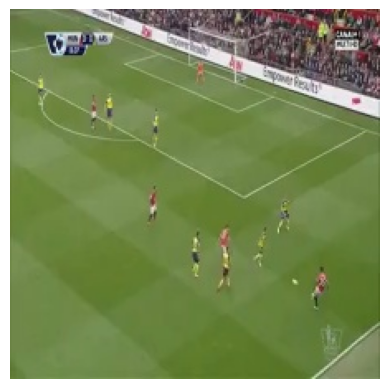

In [94]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(df.iloc[0]["image_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

# Pytorch Data Transformation and Custom Dataset Definition

In [95]:
%pip install torch torchvision torchaudio

import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [96]:
# ImageNet normalization expected by the pretrained ResNet weights
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [97]:
train_csv = dataset_path / "processed_frames" / "train" / "labels.csv"
valid_csv = dataset_path / "processed_frames" / "valid" / "labels.csv"
test_csv  = dataset_path / "processed_frames" / "test" / "labels.csv"

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

print(train_df.head())

                                          image_path  label  action_id    clip
0  /Users/rishideshpande/Downloads/data/soccernet...      1          0  clip_1
1  /Users/rishideshpande/Downloads/data/soccernet...      1          0  clip_1
2  /Users/rishideshpande/Downloads/data/soccernet...      1          0  clip_1
3  /Users/rishideshpande/Downloads/data/soccernet...      1          0  clip_1
4  /Users/rishideshpande/Downloads/data/soccernet...      1          0  clip_1


In [98]:
# Define Custom PyTorch Dataset subclass
class SoccerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe) # Total number of individual frame images

    def __getitem__(self, idx):
        # Retrieve image path and target label for a given index
        image_path = self.dataframe.iloc[idx]["image_path"]
        label = self.dataframe.iloc[idx]["label"]

        image = Image.open(image_path).convert("RGB")

        # Apply transformations (ToTensor + Normalize)
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# DataLoader and Verification

In [99]:
# Instantiate custom datasets
train_dataset = SoccerDataset(train_df, transform=transform)
valid_dataset = SoccerDataset(valid_df, transform=transform)
test_dataset = SoccerDataset(test_df, transform=transform)

In [100]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(1)


In [101]:
# Wrap datasets in DataLoaders (handles batching, parallel worker processing, and shuffling)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [102]:
# Fetch a single batch from the train loader to verify tensor dimensions
images, labels = next(iter(train_loader))

print(images.shape) # Output: torch.Size([32, 3, 224, 224]) -> [Batch Size, Channels, Height, Width]
print(labels.shape) # Output: torch.Size([32]) -> [Batch Size]

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Image Un-Normalization and Batch Visualization

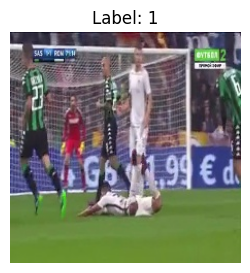

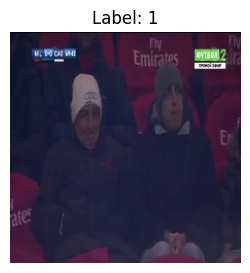

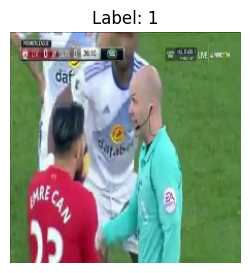

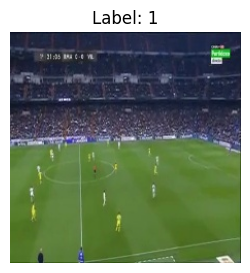

In [103]:
import matplotlib.pyplot as plt

# Grab first batch
images, labels = next(iter(train_loader))

imagenet_mean = torch.tensor([0.485, 0.456, 0.406])
imagenet_std = torch.tensor([0.229, 0.224, 0.225])

for i in range(4):
    img = images[i].permute(1, 2, 0)     # CHW -> HWC
    img = img * imagenet_std + imagenet_mean  # Undo ImageNet normalization
    img = img.clamp(0, 1)
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

In [104]:
import torch.nn as nn
from torchvision import models

In [105]:
model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze the pretrained feature extractor for this first baseline.
for parameter in model.parameters():
    parameter.requires_grad = False

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [106]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [107]:
# The new classification layer remains trainable by default.
model.fc = nn.Linear(model.fc.in_features, 2)

In [108]:
# Reuse the device selected during setup (MPS, CUDA, or CPU).
model = model.to(device)

In [109]:
images, labels = next(iter(train_loader))
images = images.to(device)
outputs = model(images)
print(outputs.shape)

torch.Size([32, 2])


In [122]:
import torch
import torch.nn as nn

# Count the actual frame samples used by the training DataLoader.
# minlength=2 guarantees the order [No offence (0), Offence (1)].
class_counts = torch.tensor(
    np.bincount(train_df["label"].astype(int), minlength=2),
    dtype=torch.float
)

# Compute inverse-frequency weights
weights = class_counts.sum() / (2 * class_counts)
weights = weights.to(device)

print("Class weights:", weights)

criterion = nn.CrossEntropyLoss(weight=weights)
# Only optimize the new classification head while the backbone is frozen.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

Class weights: tensor([4.3503, 0.5649])
Class weights: tensor([4.3503, 0.5649])


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(valid_loader)
    val_accuracy = 100 * correct / total


    # Print Results
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")



Epoch [1/1]
Train Loss: 0.3106
Train Accuracy: 89.27%
Validation Loss: 0.4019
Validation Accuracy: 88.16%


In [113]:
# -----------------------------
# Testing
# -----------------------------

model.eval()

running_test_loss = 0.0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = running_test_loss / len(test_loader)

print(f"\nTest Loss: {test_loss:.4f}")


Test Loss: 0.3791


In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
balanced_accuracy = balanced_accuracy_score(all_labels, all_predictions)
macro_f1 = f1_score(all_labels, all_predictions, average="macro")

# Majority baseline: predict the most frequent test label for every frame.
majority_label = pd.Series(all_labels).mode().iloc[0]
majority_predictions = np.full(len(all_labels), majority_label)
majority_accuracy = accuracy_score(all_labels, majority_predictions)
majority_balanced_accuracy = balanced_accuracy_score(
    all_labels, majority_predictions
)

print("\n===== FINAL TEST METRICS =====")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced accuracy : {balanced_accuracy:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")

print("\n===== MAJORITY-CLASS BASELINE =====")
print(f"Majority label             : {majority_label}")
print(f"Baseline accuracy          : {majority_accuracy:.4f}")
print(f"Baseline balanced accuracy : {majority_balanced_accuracy:.4f}")

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["No offence", "Offence"],
    zero_division=0
))


===== FINAL TEST METRICS =====
Accuracy : 0.8989
Precision: 0.9092
Recall   : 0.9873
F1 Score : 0.9466

Classification Report
              precision    recall  f1-score   support

           0       0.17      0.03      0.05       756
           1       0.91      0.99      0.95      7464

    accuracy                           0.90      8220
   macro avg       0.54      0.51      0.50      8220
weighted avg       0.84      0.90      0.86      8220



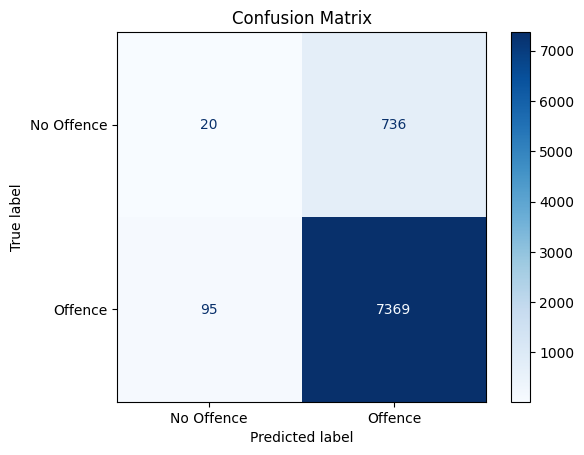

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Offence", "Offence"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()